In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

In [2]:
GSEA_FOLDER = "gsea_results_S1_C8celltypemerged"
FILE_GLOB = "*.csv"

# Which enrichment score to use as the program->pathway embedding
SCORE_COL = "NES"

# Similarity settings: "pearson" or "cosine" or "spearman"
SIMILARITY = "spearman"

# Hierarchy logic:
HI_THRESH = 0.90      # if best similarity >= HI_THRESH -> single green edge
MAX_PARENTS = 3       # if best similarity < HI_THRESH -> keep top 3 parents
MIN_SIM = None        # optional: drop edges below this (only applies in multi-parent case)

K_MIN = None
K_MAX = 10

# Output
OUT_EDGES_CSV = "gep_tree_edges_from_gsea.csv"

In [3]:
def load_gsea_folder(folder: str, file_glob="*.csv") -> pd.DataFrame:
    folder = Path(folder)
    files = sorted(folder.glob(file_glob))
    if not files:
        raise FileNotFoundError(f"No files matched {file_glob} in {folder}")

    dfs = []
    for fp in files:
        if fp.suffix.lower() in [".csv", ".tsv", ".txt"]:
            df = pd.read_csv(fp)
        elif fp.suffix.lower() in [".xlsx", ".xls"]:
            df = pd.read_excel(fp)
        else:
            raise ValueError(f"Unsupported file type: {fp}")

        df["__source_file__"] = fp.name
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)
    return out

gsea_all = load_gsea_folder(GSEA_FOLDER, FILE_GLOB)
print("Loaded rows:", len(gsea_all))
print("Columns:", list(gsea_all.columns))
gsea_all.head()

Loaded rows: 271388
Columns: ['K', 'GEP', 'pathway', 'NES', 'pval', 'fdr', 'Name', 'ES', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes', 'spectra_file', '__source_file__']


,K,GEP,pathway,NES,pval,fdr,Name,ES,FWER p-val,Tag %,Gene %,Lead_genes,spectra_file,__source_file__
0,10,1,CTX_BIG_GROUPS_BRAIN_IMMUNE,-3.354363,0.0,0.0,prerank,-0.774997,0.0,73/97,11.14%,ARHGEF1;AKNA;CD74;IL2RG;CORO1A;ACAP1;ARHGAP15;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
1,10,1,INTESTINE_ADULT_CI_MESENCHYMAL,-3.269914,0.0,0.0,prerank,-0.635208,0.0,179/261,18.12%,LAPTM5;CORO1A;ACAP1;ARHGAP15;TMC8;WIPF1;ITGAL;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
2,10,1,LYMPHOID,-3.259176,0.0,0.0,prerank,-0.658085,0.0,158/238,21.28%,ARHGEF1;IL2RG;CORO1A;TMC8;RAC2;LTB;SEPTIN1;IL3...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
3,10,1,B_T,-3.221652,0.0,0.0,prerank,-0.743866,0.0,106/123,21.24%,ARHGEF1;LAPTM5;IL2RG;CORO1A;ACAP1;ARHGAP15;TMC...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
4,10,1,OLFACTORY_NEUROEPITHELIUM_CD8_T,-3.084729,0.0,0.0,prerank,-0.733769,0.0,53/67,18.34%,LAPTM5;IL2RG;CORO1A;ACAP1;RAC2;IL32;TRAF3IP3;T...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv


In [4]:
gsea_all = gsea_all.drop(columns=['Name'])
gsea_all.head()

,K,GEP,pathway,NES,pval,fdr,ES,FWER p-val,Tag %,Gene %,Lead_genes,spectra_file,__source_file__
0,10,1,CTX_BIG_GROUPS_BRAIN_IMMUNE,-3.354363,0.0,0.0,-0.774997,0.0,73/97,11.14%,ARHGEF1;AKNA;CD74;IL2RG;CORO1A;ACAP1;ARHGAP15;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
1,10,1,INTESTINE_ADULT_CI_MESENCHYMAL,-3.269914,0.0,0.0,-0.635208,0.0,179/261,18.12%,LAPTM5;CORO1A;ACAP1;ARHGAP15;TMC8;WIPF1;ITGAL;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
2,10,1,LYMPHOID,-3.259176,0.0,0.0,-0.658085,0.0,158/238,21.28%,ARHGEF1;IL2RG;CORO1A;TMC8;RAC2;LTB;SEPTIN1;IL3...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
3,10,1,B_T,-3.221652,0.0,0.0,-0.743866,0.0,106/123,21.24%,ARHGEF1;LAPTM5;IL2RG;CORO1A;ACAP1;ARHGAP15;TMC...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
4,10,1,OLFACTORY_NEUROEPITHELIUM_CD8_T,-3.084729,0.0,0.0,-0.733769,0.0,53/67,18.34%,LAPTM5;IL2RG;CORO1A;ACAP1;RAC2;IL32;TRAF3IP3;T...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv


In [5]:
def build_k_to_matrix(df: pd.DataFrame, score_col="NES") -> dict[int, pd.DataFrame]:
    df = df.copy()

    # Unique program id (so program names don't collide across K)
    df["program_id"] = df.apply(lambda r: f"K{int(r['K'])}_GEP{int(r['GEP'])}", axis=1)

    k_to_mat = {}
    for k, sub in df.groupby("K"):
        mat = sub.pivot_table(
            index="program_id",
            columns="pathway",
            values=score_col,
            aggfunc="max"
        )
        mat = mat.fillna(0.0)
        k_to_mat[int(k)] = mat

    return k_to_mat

k_to_mat = build_k_to_matrix(gsea_all, score_col=SCORE_COL)

print("Built matrices for Ks:", sorted(k_to_mat.keys())[:10], "..." )
some_k = sorted(k_to_mat.keys())[0]
print("Example K:", some_k, "shape:", k_to_mat[some_k].shape)
k_to_mat[some_k].iloc[:5, :5]

Built matrices for Ks: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14] ...
Example K: 5 shape: (5, 614)


pathway,5TH_WEEK_CARDIAC,ACINAR,ACTC_POS_SMC,ACTIVATED_NK,ADC_1
program_id,,,,,
K5_GEP1,-2.043504,-2.574712,-1.565387,1.665727,1.572486
K5_GEP2,1.934443,1.262682,1.397989,-0.994788,-1.612891
K5_GEP3,1.252091,2.170022,1.184143,0.462271,1.299113
K5_GEP4,0.651651,-1.000000,1.443512,-1.163124,0.426900
K5_GEP5,-1.948572,-1.000000,-1.155978,1.305203,1.300643


In [6]:
all_ks = sorted(k_to_mat.keys())
kmin = K_MIN if K_MIN is not None else min(all_ks)
kmax = K_MAX if K_MAX is not None else max(all_ks)

k_chain = [k for k in range(kmin, kmax + 1) if k in k_to_mat]
print("Using K chain:", k_chain)

Using K chain: [5, 6, 7, 8, 9, 10]


In [7]:
def cosine_similarity_matrix(B: np.ndarray, A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Returns C = cosine similarity between each row of B and each row of A.
    Output shape: (B_rows, A_rows).
    """
    A_norm = A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)
    B_norm = B / (np.linalg.norm(B, axis=1, keepdims=True) + eps)
    return B_norm @ A_norm.T

def pearson_similarity_matrix(B: np.ndarray, A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Pearson correlation between rows of B and rows of A.
    Output shape: (B_rows, A_rows).
    """
    A0 = A - A.mean(axis=1, keepdims=True)
    B0 = B - B.mean(axis=1, keepdims=True)

    A_den = np.linalg.norm(A0, axis=1, keepdims=True) + eps
    B_den = np.linalg.norm(B0, axis=1, keepdims=True) + eps

    A1 = A0 / A_den
    B1 = B0 / B_den
    return B1 @ A1.T

def _rank_rows_dense(X: np.ndarray) -> np.ndarray:
    """
    Dense ranks per row (ties get same rank). Uses pandas for robust tie handling.
    """
    return pd.DataFrame(X).rank(axis=1, method="dense").to_numpy(dtype=float)

def spearman_similarity_matrix(B: np.ndarray, A: np.ndarray) -> np.ndarray:
    """
    Spearman correlation = Pearson correlation of per-row ranks.
    Output shape: (B_rows, A_rows).
    """
    Br = _rank_rows_dense(B)
    Ar = _rank_rows_dense(A)
    return pearson_similarity_matrix(Br, Ar)

def similarity_matrix(df_child: pd.DataFrame, df_parent: pd.DataFrame, method="pearson") -> pd.DataFrame:
    # align pathway columns
    common = df_child.columns.intersection(df_parent.columns)
    if len(common) == 0:
        raise ValueError("No overlapping pathway columns between child and parent matrices.")

    B = df_child[common].to_numpy(dtype=float)
    A = df_parent[common].to_numpy(dtype=float)

    method = method.lower().strip()
    if method == "cosine":
        C = cosine_similarity_matrix(B, A)
    elif method == "pearson":
        C = pearson_similarity_matrix(B, A)
    elif method == "spearman":
        C = spearman_similarity_matrix(B, A)
    else:
        raise ValueError("method must be one of: 'pearson', 'cosine', 'spearman'")

    return pd.DataFrame(C, index=df_child.index, columns=df_parent.index)

print("Similarity method:", SIMILARITY)

Similarity method: spearman


In [8]:
def build_tree_edges_multi(
    k_to_mat: dict[int, pd.DataFrame],
    k_chain: list[int],
    sim_method: str = "pearson",
    hi_thresh: float = 0.90,
    max_parents: int = 3,
    min_sim=None,
    low_rank_colors=("purple", "red", "pink"),
    hi_color="green",
) -> pd.DataFrame:
    """
    For each child program at K+1:
      - if best similarity >= hi_thresh: connect ONLY best parent, color green
      - else: connect top `max_parents` parents, color purple/red/pink by rank
    """
    edges = []

    for k in k_chain[:-1]:
        if (k not in k_to_mat) or (k + 1 not in k_to_mat):
            continue

        parent = k_to_mat[k]
        child  = k_to_mat[k + 1]

        sim = similarity_matrix(child, parent, method=sim_method)  # rows=child, cols=parent

        for child_id, row in sim.iterrows():
            row_sorted = row.sort_values(ascending=False)

            best_parent = row_sorted.index[0]
            best_sim = float(row_sorted.iloc[0])

            if best_sim >= hi_thresh:
                edges.append({
                    "parent_k": k,
                    "child_k": k + 1,
                    "parent_id": best_parent,
                    "child_id": child_id,
                    "similarity": best_sim,
                    "rank": 1,
                    "color": hi_color,
                    "mode": "high"
                })
            else:
                top = row_sorted.head(max_parents)

                # optional filter only for multi-parent case
                if min_sim is not None:
                    top = top[top >= float(min_sim)]
                    if top.empty:
                        top = row_sorted.head(1)

                for rnk, (pid, sval) in enumerate(top.items(), start=1):
                    color = low_rank_colors[rnk - 1] if rnk <= len(low_rank_colors) else low_rank_colors[-1]
                    edges.append({
                        "parent_k": k,
                        "child_k": k + 1,
                        "parent_id": pid,
                        "child_id": child_id,
                        "similarity": float(sval),
                        "rank": rnk,
                        "color": color,
                        "mode": "low"
                    })

    return pd.DataFrame(edges)

edges_df = build_tree_edges_multi(
    k_to_mat=k_to_mat,
    k_chain=k_chain,
    sim_method=SIMILARITY,
    hi_thresh=HI_THRESH,
    max_parents=MAX_PARENTS,
    min_sim=MIN_SIM
)

print("Edges:", len(edges_df))
edges_df.head(10)

Edges: 52


,parent_k,child_k,parent_id,child_id,similarity,rank,color,mode
0,5,6,K5_GEP1,K6_GEP1,0.999443,1,green,high
1,5,6,K5_GEP2,K6_GEP2,0.993515,1,green,high
2,5,6,K5_GEP3,K6_GEP3,0.998010,1,green,high
3,5,6,K5_GEP4,K6_GEP4,0.995685,1,green,high
4,5,6,K5_GEP5,K6_GEP5,0.997624,1,green,high
5,5,6,K5_GEP3,K6_GEP6,0.465350,1,purple,low
6,5,6,K5_GEP5,K6_GEP6,0.229339,2,red,low
7,5,6,K5_GEP4,K6_GEP6,0.008229,3,pink,low
8,6,7,K6_GEP2,K7_GEP1,0.996489,1,green,high
9,6,7,K6_GEP1,K7_GEP2,0.938283,1,green,high


In [9]:
if len(edges_df) == 0:
    print("No edges built. Common causes: no overlapping pathways across K, or MIN_SIM too high.")
else:
    vc = edges_df["child_id"].value_counts()
    print("Children with 1 edge:", int((vc == 1).sum()))
    print("Children with 2 edges:", int((vc == 2).sum()))
    print("Children with 3+ edges:", int((vc >= 3).sum()))
    print("Total children connected:", int(vc.shape[0]))

Children with 1 edge: 34
Children with 2 edges: 0
Children with 3+ edges: 6
Total children connected: 40


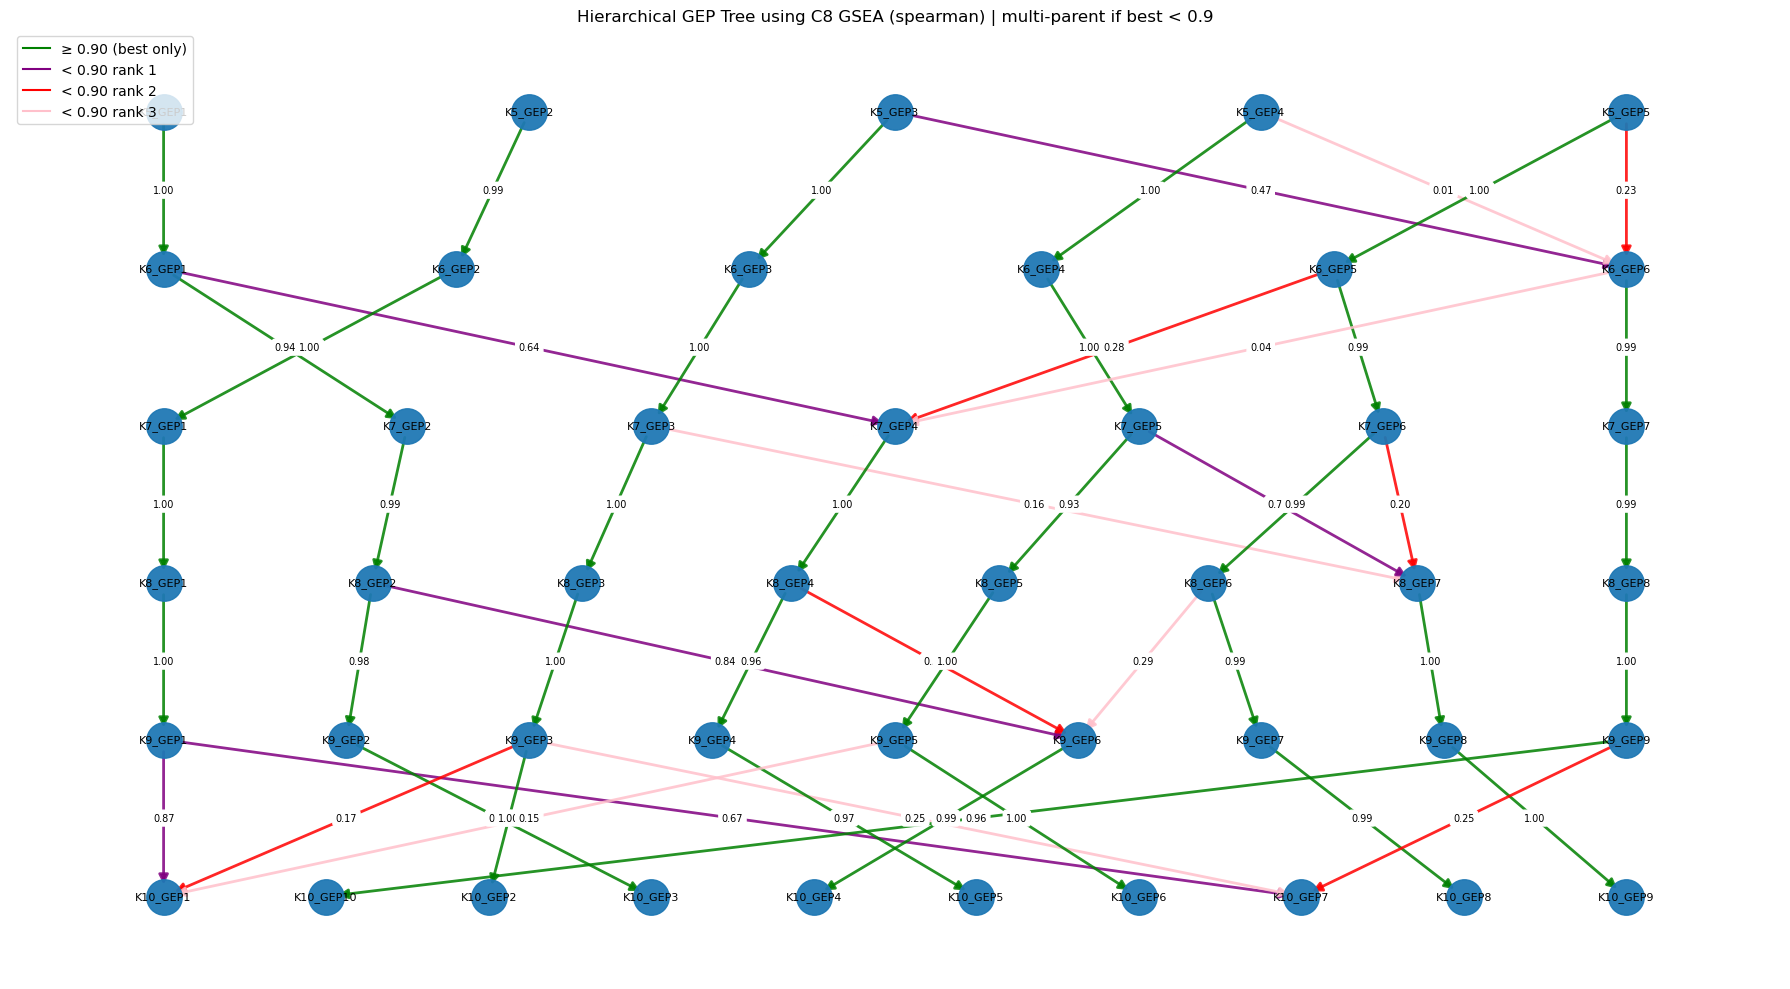

In [10]:
def plot_tree(edges_df: pd.DataFrame, title: str, figsize=(18, 10)):
    if edges_df is None or len(edges_df) == 0:
        print("No edges to plot.")
        return

    G = nx.DiGraph()

    # Add nodes with level attribute (K)
    for _, e in edges_df.iterrows():
        G.add_node(e["parent_id"], level=int(e["parent_k"]))
        G.add_node(e["child_id"],  level=int(e["child_k"]))

        # DiGraph doesn't support true parallel edges; rank makes edges unique conceptually,
        # but we'll still add them normally (many will share same u->v only if ties).
        G.add_edge(
            e["parent_id"], e["child_id"],
            similarity=float(e["similarity"]),
            color=e["color"],
            rank=int(e["rank"])
        )

    # Build a top-down layout: group by level (K)
    levels = {}
    for n, d in G.nodes(data=True):
        levels.setdefault(d["level"], []).append(n)
    for k in levels:
        levels[k] = sorted(levels[k])

    sorted_levels = sorted(levels.keys())
    pos = {}
    for li, k in enumerate(sorted_levels):
        nodes = levels[k]
        xs = [0.5] if len(nodes) == 1 else np.linspace(0.05, 0.95, len(nodes))
        y = -li
        for x, n in zip(xs, nodes):
            pos[n] = (float(x), float(y))

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.set_title(title)

    nx.draw_networkx_nodes(G, pos, node_size=650, alpha=0.95)
    nx.draw_networkx_labels(G, pos, font_size=8)

    edgelist = list(G.edges())
    edge_colors = [G.edges[u, v]["color"] for u, v in edgelist]
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edgelist,
        edge_color=edge_colors,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=14,
        width=2.0,
        alpha=0.85
    )

    edge_labels = {(u, v): f'{G.edges[u, v]["similarity"]:.2f}' for u, v in edgelist}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, rotate=False)

    # Legend
    import matplotlib.lines as mlines
    handles = [
        mlines.Line2D([], [], color="green",  label=f"≥ {HI_THRESH:.2f} (best only)"),
        mlines.Line2D([], [], color="purple", label=f"< {HI_THRESH:.2f} rank 1"),
        mlines.Line2D([], [], color="red",    label=f"< {HI_THRESH:.2f} rank 2"),
        mlines.Line2D([], [], color="pink",   label=f"< {HI_THRESH:.2f} rank 3"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=True)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_tree(
    edges_df,
    title=f"Hierarchical GEP Tree using C8 GSEA ({SIMILARITY}) | multi-parent if best < {HI_THRESH}"
)


In [11]:
# # --- Build a clustree-ready table: rows=pathways, columns=K5..K10 (or whatever k_chain is) ---
# import re
# import numpy as np
# import pandas as pd

# OUT_CLUSTREE_CSV = "clustree_export_R_proj/clustree_input_pathways_by_bestGEP.csv"

# def _extract_gep_int(program_id: str) -> int:
#     """
#     program_id looks like 'K7_GEP12' (built earlier in your notebook).
#     Return 12 as an int.
#     """
#     m = re.search(r"_GEP(\d+)$", str(program_id))
#     return int(m.group(1)) if m else np.nan

# # Union of pathways across the K's you're using
# all_pathways = sorted(set().union(*[set(k_to_mat[k].columns) for k in k_chain]))

# clustree_df = pd.DataFrame({"pathway": all_pathways}).set_index("pathway")

# for k in k_chain:
#     mat = k_to_mat[k]  # rows=program_id, cols=pathway, values=NES (or SCORE_COL)
#     # For each pathway, pick the program_id (row) with max score
#     best_program = mat.idxmax(axis=0)  # index=pathway, value=program_id
#     # Convert K?_GEP? -> integer cluster id for clustree
#     clustree_df[f"K{k}"] = best_program.map(_extract_gep_int).astype("Int64")

# # Optional sanity checks
# print("clustree_df shape:", clustree_df.shape)
# print("K columns:", [c for c in clustree_df.columns if c.startswith("K")])
# print(clustree_df.head())

# clustree_df.to_csv(OUT_CLUSTREE_CSV)
# print("Wrote:", OUT_CLUSTREE_CSV)

### annotate tree with cell type at each GEP

- go through usage matrix and get the GEPs
- subset top 25% of cells used in the GEPs
- overlap with metadata csv and get the cell type
- attach cell type to GEP

In [12]:
USAGE_FOLDER = "all_datasets_consensus/anal_pc5_c21_S1.filtered_consensus_outputs"
METADATA_CSV = "data/anal_cancer_n21_meta.csv" 
CELLTYPE_COL = "cluster_annot3"  

# Parameters
TOP_CELLS_FRACTION = 0.10  # Top 10% of cells (change to 0.25 for 25%)
TOP_N_CELLTYPES = 3        # Number of top cell types to attach

# Output
OUT_CELLTYPE_CSV = "gsea_results_S1_C8celltypemerged/gep_celltype_annotations.csv"

In [13]:
def load_usage_matrix(folder: str, k: int) -> pd.DataFrame:
    """Load usage matrix for a specific K value."""
    folder = Path(folder)
    pattern = f"*.usages.k_{k}.dt_0_01.consensus.txt"
    files = list(folder.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No usage file found for K={k}")
    
    return pd.read_csv(files[0], sep='\t', index_col=0)


def load_metadata(csv_path: str, celltype_col: str) -> pd.Series:
    """Load metadata and return cell barcode -> cell type mapping."""
    meta = pd.read_csv(csv_path, index_col=0)
    if celltype_col not in meta.columns:
        raise ValueError(f"Column '{celltype_col}' not found. Available: {list(meta.columns)}")
    return meta[celltype_col]


# Load metadata
print(f"Loading metadata from: {METADATA_CSV}")
cell_to_type = load_metadata(METADATA_CSV, CELLTYPE_COL)
print(f"Loaded {len(cell_to_type)} cells with {cell_to_type.nunique()} unique cell types")

Loading metadata from: data/anal_cancer_n21_meta.csv
Loaded 304634 cells with 19 unique cell types


/var/folders/bw/grhyggnj06ncywf0093kz3ch0000gn/T/ipykernel_57584/2555323122.py:15: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(csv_path, index_col=0)


In [14]:
def get_top_celltypes_for_gep(
    usage_series: pd.Series,
    cell_to_type: pd.Series,
    top_fraction: float = 0.10,
    top_n: int = 3
) -> list[tuple[str, float]]:
    """
    Return [(celltype, proportion_among_top_cells), ...] for the top-usage cells of one GEP.
    """
    # Ensure numeric
    s = pd.to_numeric(usage_series, errors="coerce").fillna(0.0)

    n_cells = len(s)
    if n_cells == 0:
        return [("Unknown", 1.0)]

    # How many "top" cells to consider
    n_top = max(1, int(np.ceil(n_cells * float(top_fraction))))
    top_cells = s.sort_values(ascending=False).head(n_top).index

    # Intersect with metadata index
    common_cells = top_cells.intersection(cell_to_type.index)
    if len(common_cells) == 0:
        return [("Unknown", 1.0)]

    top_cell_types = cell_to_type.loc[common_cells].astype(str)
    type_counts = Counter(top_cell_types)
    total = sum(type_counts.values()) or 1

    return [(ct, count / total) for ct, count in type_counts.most_common(top_n)]


def format_celltype_annotation(top_types: list[tuple[str, float]]) -> str:
    """Format as: 'T_cell (45%), B_cell (30%), Macrophage (15%)'"""
    return ", ".join([f"{ct} ({prop*100:.0f}%)" for ct, prop in top_types])


In [15]:
def _detect_gep_column_indexing(cols) -> str:
    """
    Detect whether usage_df columns are 0-indexed (0..K-1) or 1-indexed (1..K).
    Returns: "zero", "one", or "unknown"
    """
    col_ints = []
    for c in cols:
        try:
            col_ints.append(int(c))
        except Exception:
            pass

    if not col_ints:
        return "unknown"

    mn = min(col_ints)
    if mn == 0:
        return "zero"
    if mn == 1:
        return "one"
    return "unknown"

In [16]:
def annotate_all_geps(
    usage_folder: str,
    cell_to_type: pd.Series,
    k_values: list[int],
    top_fraction: float = 0.10,
    top_n: int = 3
) -> pd.DataFrame:
    """
    Annotate all GEPs across all K values with top cell types.

    Expected usage file format:
      - first column = cell barcode (index)
      - columns = 0..K-1 OR 1..K (we detect and handle both)
    """
    results = []

    for k in k_values:
        print(f"Processing K={k}...", end=" ")

        # Uses your existing helper if present; otherwise falls back to glob
        if "load_usage_matrix" in globals():
            usage_df = load_usage_matrix(usage_folder, k)
        else:
            folder = Path(usage_folder)
            pattern = f"*.usages.k_{k}.dt_0_01.consensus.txt"
            files = list(folder.glob(pattern))
            if not files:
                raise FileNotFoundError(f"No usage file found for K={k} in {usage_folder}")
            usage_df = pd.read_csv(files[0], sep="\t", index_col=0)

        # Detect indexing style once per K
        indexing = _detect_gep_column_indexing(usage_df.columns)
        print(f"columns look {indexing}-indexed", end="; ")

        for col in usage_df.columns:
            # determine GEP number robustly
            if indexing == "zero":
                # columns are 0..K-1 -> GEP number should be +1
                try:
                    gep_num = int(col) + 1
                except Exception:
                    gep_num = list(usage_df.columns).index(col) + 1
            elif indexing == "one":
                # columns are already 1..K -> keep as-is
                try:
                    gep_num = int(col)
                except Exception:
                    gep_num = list(usage_df.columns).index(col) + 1
            else:
                # fallback: positional
                gep_num = list(usage_df.columns).index(col) + 1

            program_id = f"K{k}_GEP{gep_num}"

            top_types = get_top_celltypes_for_gep(
                usage_df[col],
                cell_to_type,
                top_fraction=top_fraction,
                top_n=top_n
            )

            results.append({
                "K": k,
                "GEP": f"GEP{gep_num}",
                "program_id": program_id,
                "gep_col": str(col),
                "top1_celltype": top_types[0][0] if top_types else "Unknown",
                "top_celltypes": format_celltype_annotation(top_types),
                "top_celltypes_list": top_types,
            })

        print("done")

    return pd.DataFrame(results)

In [17]:
ks_to_annotate = k_chain if "k_chain" in globals() else list(range(5, 22))

print(f"\nAnnotating GEPs for K={ks_to_annotate}")
print(f"Using top {TOP_CELLS_FRACTION*100:.0f}% of cells, attaching top {TOP_N_CELLTYPES} cell types\n")

gep_annotations = annotate_all_geps(
    USAGE_FOLDER,
    cell_to_type,
    ks_to_annotate,
    top_fraction=TOP_CELLS_FRACTION,
    top_n=TOP_N_CELLTYPES
)

print(f"\nAnnotated {len(gep_annotations)} GEPs")
display(gep_annotations.head(10))


Annotating GEPs for K=[5, 6, 7, 8, 9, 10]
Using top 10% of cells, attaching top 3 cell types

Processing K=5... columns look one-indexed; done
Processing K=6... columns look one-indexed; done
Processing K=7... columns look one-indexed; done
Processing K=8... columns look one-indexed; done
Processing K=9... columns look one-indexed; done
Processing K=10... columns look one-indexed; done

Annotated 45 GEPs


,K,GEP,program_id,gep_col,top1_celltype,top_celltypes,top_celltypes_list
0,5,GEP1,K5_GEP1,1,Bcells_CD19,"Bcells_CD19 (23%), CD4+Tcells (22%), CD8+Tcell...","[(Bcells_CD19, 0.22701555869872703), (CD4+Tcel..."
1,5,GEP2,K5_GEP2,2,Tumor/Epithelials,"Tumor/Epithelials (98%), Fibroblasts/Stromal (...","[(Tumor/Epithelials, 0.9809052333804809), (Fib..."
2,5,GEP3,K5_GEP3,3,Tumor/Epithelials,"Tumor/Epithelials (100%), Endothelials (0%), F...","[(Tumor/Epithelials, 0.9957567185289957), (End..."
3,5,GEP4,K5_GEP4,4,Fibroblasts/Stromal,"Fibroblasts/Stromal (75%), Endothelials (18%),...","[(Fibroblasts/Stromal, 0.7545968882602546), (E..."
4,5,GEP5,K5_GEP5,5,Tumor/Epithelials,"Tumor/Epithelials (33%), Mac_C1Q_ZEB2 (15%), E...","[(Tumor/Epithelials, 0.32673267326732675), (Ma..."
5,6,GEP1,K6_GEP1,1,Bcells_CD19,"Bcells_CD19 (23%), CD4+Tcells (21%), CD8+Tcell...","[(Bcells_CD19, 0.22842998585572843), (CD4+Tcel..."
6,6,GEP2,K6_GEP2,2,Tumor/Epithelials,"Tumor/Epithelials (98%), Fibroblasts/Stromal (...","[(Tumor/Epithelials, 0.9787835926449788), (Fib..."
7,6,GEP3,K6_GEP3,3,Tumor/Epithelials,"Tumor/Epithelials (100%), Endothelials (0%), F...","[(Tumor/Epithelials, 0.995049504950495), (Endo..."
8,6,GEP4,K6_GEP4,4,Fibroblasts/Stromal,"Fibroblasts/Stromal (75%), Endothelials (18%),...","[(Fibroblasts/Stromal, 0.7538896746817539), (E..."
9,6,GEP5,K6_GEP5,5,Tumor/Epithelials,"Tumor/Epithelials (33%), Mac_C1Q_ZEB2 (15%), E...","[(Tumor/Epithelials, 0.32531824611032534), (Ma..."


In [18]:
# Save annotations
gep_annotations.to_csv(OUT_CELLTYPE_CSV, index=False)
print(f"Saved to: {OUT_CELLTYPE_CSV}")

# Create lookup dictionaries
gep_to_celltype = dict(zip(gep_annotations["program_id"], gep_annotations["top_celltypes"]))  # was celltype_string
gep_to_top1     = dict(zip(gep_annotations["program_id"], gep_annotations["top1_celltype"]))

Saved to: gsea_results_S1_C8celltypemerged/gep_celltype_annotations.csv


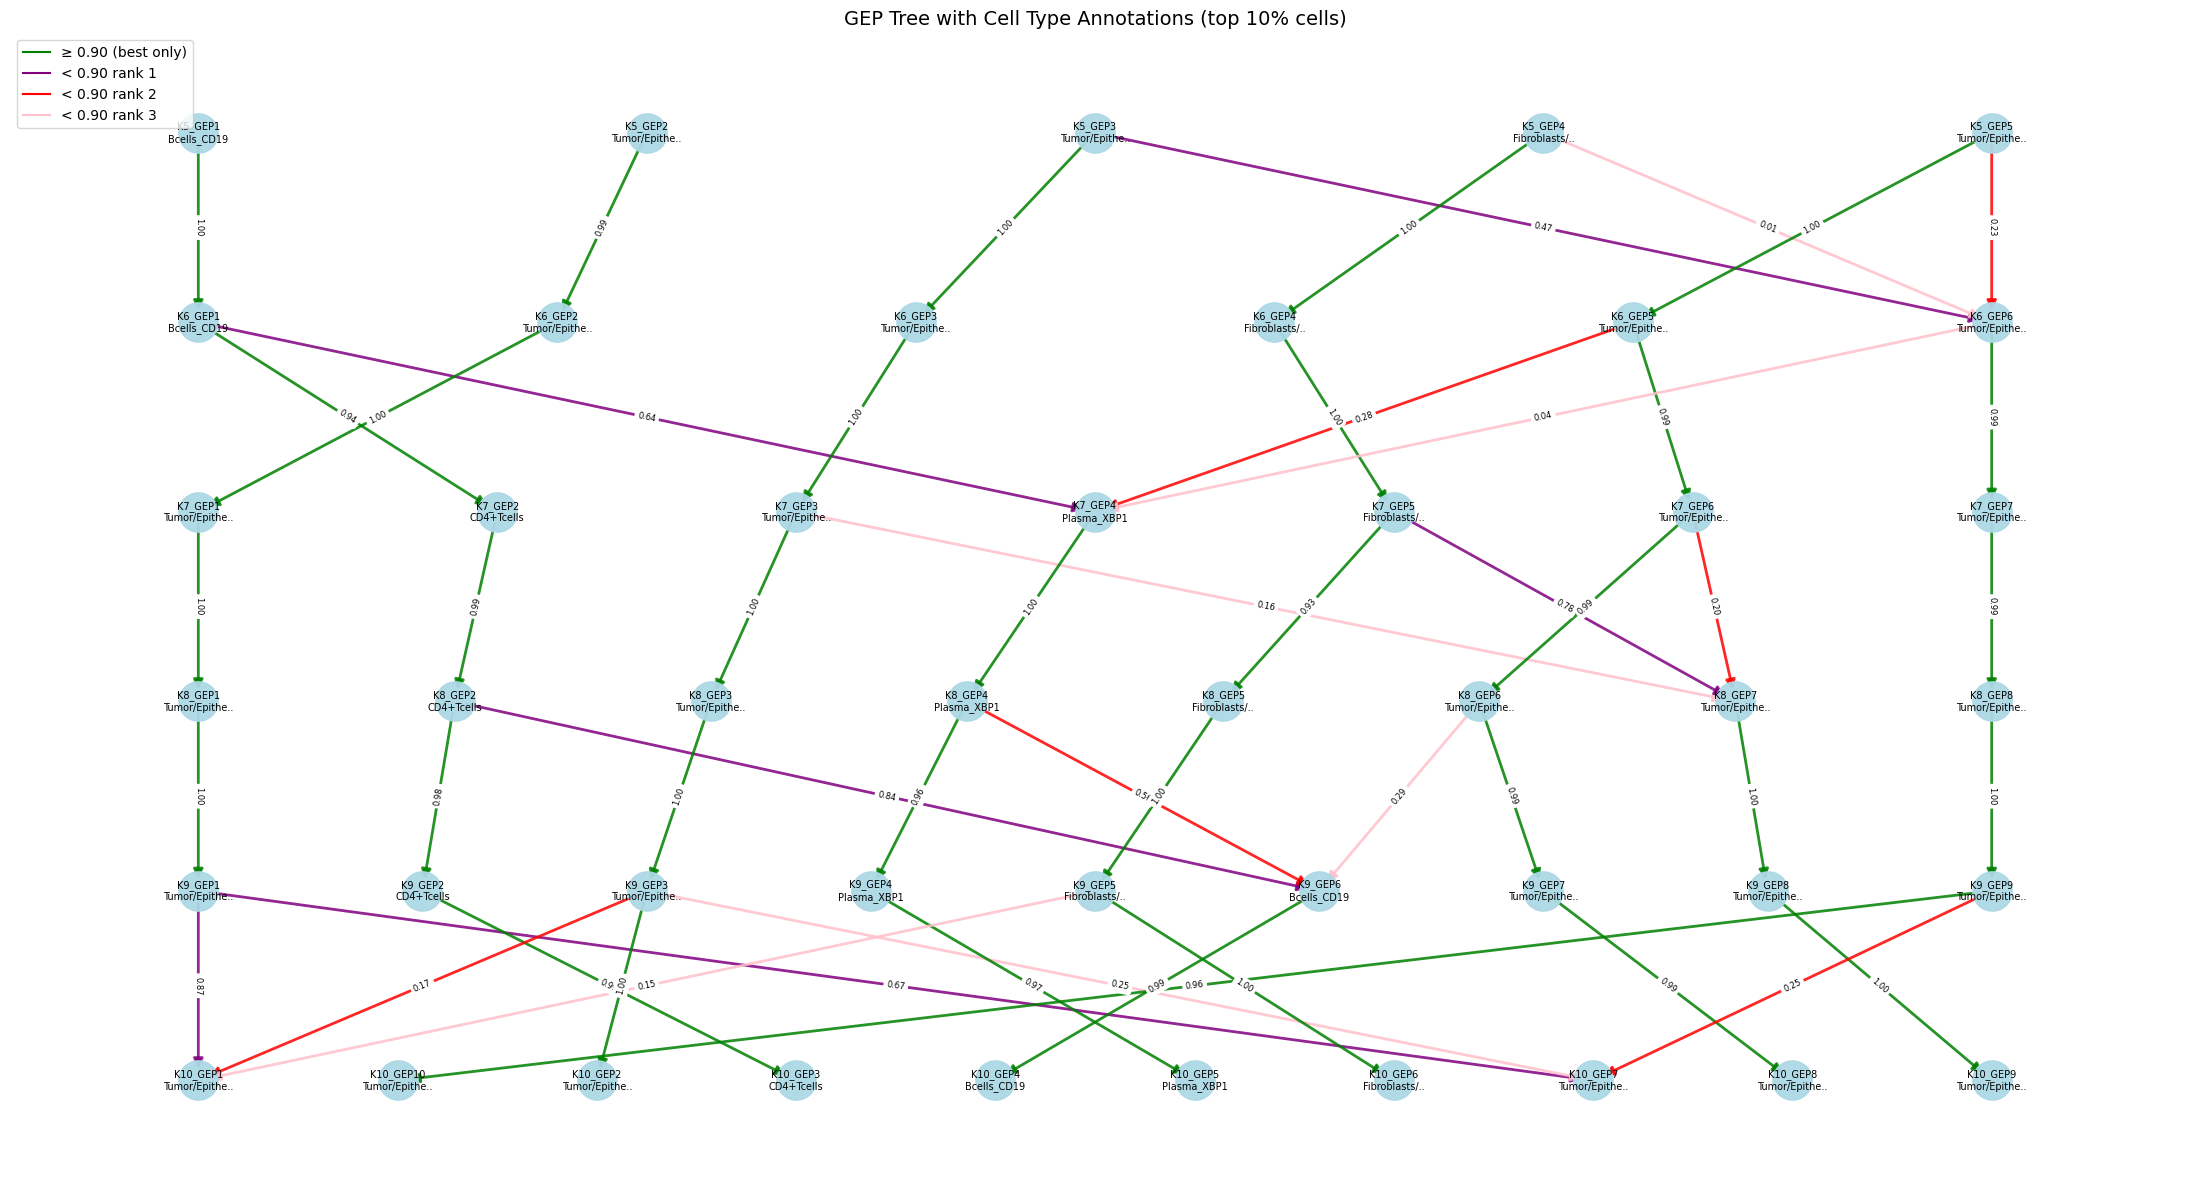

In [19]:
def plot_tree_with_celltypes(
    edges_df: pd.DataFrame, 
    gep_to_celltype: dict,
    gep_to_top1: dict,
    title: str, 
    figsize=(22, 12),
    label_mode: str = "top1"  # "top1", "full", or "none"
):
    """Plot GEP tree with cell type annotations."""
    import matplotlib.lines as mlines
    
    if edges_df is None or len(edges_df) == 0:
        print("No edges to plot.")
        return

    G = nx.DiGraph()
    for _, e in edges_df.iterrows():
        G.add_node(e["parent_id"], level=int(e["parent_k"]))
        G.add_node(e["child_id"],  level=int(e["child_k"]))
        G.add_edge(e["parent_id"], e["child_id"],
                   similarity=float(e["similarity"]), color=e["color"], rank=int(e["rank"]))

    # Layout
    levels = {}
    for n, d in G.nodes(data=True):
        levels.setdefault(d["level"], []).append(n)
    for k in levels:
        levels[k] = sorted(levels[k])

    pos = {}
    for li, k in enumerate(sorted(levels.keys())):
        nodes = levels[k]
        xs = [0.5] if len(nodes) == 1 else np.linspace(0.05, 0.95, len(nodes))
        for x, n in zip(xs, nodes):
            pos[n] = (float(x), float(-li))

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.set_title(title, fontsize=14)

    nx.draw_networkx_nodes(G, pos, node_size=800, alpha=0.95, node_color='lightblue')
    
    # Labels with cell type
    labels = {}
    for node in G.nodes():
        if label_mode == "top1":
            top1 = gep_to_top1.get(node, "")
            top1 = top1[:12] + ".." if len(top1) > 14 else top1
            labels[node] = f"{node}\n{top1}"
        elif label_mode == "full":
            labels[node] = f"{node}\n{gep_to_celltype.get(node, '')}"
        else:
            labels[node] = node
    
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=7)

    edgelist = list(G.edges())
    edge_colors = [G.edges[u, v]["color"] for u, v in edgelist]
    nx.draw_networkx_edges(G, pos, edgelist=edgelist, edge_color=edge_colors,
                           arrows=True, arrowstyle="-|>", arrowsize=14, width=2.0, alpha=0.85)
    
    edge_labels = {(u, v): f'{G.edges[u, v]["similarity"]:.2f}' for u, v in edgelist}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

    handles = [
        mlines.Line2D([], [], color="green",  label=f"≥ {HI_THRESH:.2f} (best only)"),
        mlines.Line2D([], [], color="purple", label=f"< {HI_THRESH:.2f} rank 1"),
        mlines.Line2D([], [], color="red",    label=f"< {HI_THRESH:.2f} rank 2"),
        mlines.Line2D([], [], color="pink",   label=f"< {HI_THRESH:.2f} rank 3"),
    ]
    ax.legend(handles=handles, loc="upper left")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Plot with cell type annotations
plot_tree_with_celltypes(
    edges_df, gep_to_celltype, gep_to_top1,
    title=f"GEP Tree with Cell Type Annotations (top {TOP_CELLS_FRACTION*100:.0f}% cells)",
    label_mode="top1"
)

In [20]:
# Summary: Cell type composition per GEP
print("="*60)
print("SUMMARY: Cell Type Composition per GEP")
print("="*60)

for k in sorted(gep_annotations['K'].unique()):
    k_data = gep_annotations[gep_annotations['K'] == k]
    print(f"\nK={k}:")
    for _, row in k_data.iterrows():
        print(f"  {row['program_id']}: {row['top_celltypes']}")

# Most common top cell types
print("\n" + "="*60)
print("Most frequent TOP-1 cell types across all GEPs:")
print("="*60)
print(gep_annotations['top1_celltype'].value_counts().head(10))

SUMMARY: Cell Type Composition per GEP

K=5:
  K5_GEP1: Bcells_CD19 (23%), CD4+Tcells (22%), CD8+Tcells (20%)
  K5_GEP2: Tumor/Epithelials (98%), Fibroblasts/Stromal (1%), Endothelials (0%)
  K5_GEP3: Tumor/Epithelials (100%), Endothelials (0%), Fibroblasts/Stromal (0%)
  K5_GEP4: Fibroblasts/Stromal (75%), Endothelials (18%), Tumor/Epithelials (6%)
  K5_GEP5: Tumor/Epithelials (33%), Mac_C1Q_ZEB2 (15%), Endothelials (10%)

K=6:
  K6_GEP1: Bcells_CD19 (23%), CD4+Tcells (21%), CD8+Tcells (20%)
  K6_GEP2: Tumor/Epithelials (98%), Fibroblasts/Stromal (1%), Endothelials (1%)
  K6_GEP3: Tumor/Epithelials (100%), Endothelials (0%), Fibroblasts/Stromal (0%)
  K6_GEP4: Fibroblasts/Stromal (75%), Endothelials (18%), Tumor/Epithelials (6%)
  K6_GEP5: Tumor/Epithelials (33%), Mac_C1Q_ZEB2 (15%), Endothelials (10%)
  K6_GEP6: Tumor/Epithelials (70%), Fibroblasts/Stromal (9%), Endothelials (6%)

K=7:
  K7_GEP1: Tumor/Epithelials (98%), Fibroblasts/Stromal (1%), Endothelials (1%)
  K7_GEP2: CD4+Tcel